# Loan Approval Analysis and Prediction

 In this notebook we explore the intricacies of a loan approval dataset, uncover interesting relationships between financial variables, and ultimately build a predictive model. 


In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline




## Data Loading and Exploration
We begin by loading the dataset and performing an initial exploration. This dataset contains detailed information about loan applicants, including financial indicators such as income, credit score, and loan amount. The loan_approved column is a boolean variable that indicates whether an applicant’s loan request was approved (True) or rejected (False).

In [3]:
loan_data = pd.read_csv('data/loan_approval.csv')
loan_data.head(5)

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False


In [5]:
columns = loan_data.columns
print('Data set columns:  ', columns)

Data set columns:   Index(['name', 'city', 'income', 'credit_score', 'loan_amount',
       'years_employed', 'points', 'loan_approved'],
      dtype='object')


In [6]:
loan_data.describe()

,income,credit_score,loan_amount,years_employed,points
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,90585.977000,573.946000,25308.503000,20.441000,56.680000
std,34487.874907,160.564945,14207.320147,11.777813,18.638033
min,30053.000000,300.000000,1022.000000,0.000000,10.000000
25%,61296.250000,433.000000,12748.750000,10.000000,45.000000
50%,90387.500000,576.000000,25661.500000,21.000000,55.000000
75%,120099.750000,715.000000,37380.500000,31.000000,70.000000
max,149964.000000,850.000000,49999.000000,40.000000,100.000000


In [7]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            2000 non-null   object 
 1   city            2000 non-null   object 
 2   income          2000 non-null   int64  
 3   credit_score    2000 non-null   int64  
 4   loan_amount     2000 non-null   int64  
 5   years_employed  2000 non-null   int64  
 6   points          2000 non-null   float64
 7   loan_approved   2000 non-null   bool   
dtypes: bool(1), float64(1), int64(4), object(2)
memory usage: 111.5+ KB


In [8]:
# check null
loan_data.isnull().sum()

name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

In [10]:
# check for duplicates
loan_data.duplicated().sum()

0

In [ ]:
# Convert 'loan_approved' to integer for some analyses if needed
loan_data['loan_approved'] = loan_data['loan_approved'].astype(int)
loan_data.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,0
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,0
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,0
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,0
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,0


In [12]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            2000 non-null   object 
 1   city            2000 non-null   object 
 2   income          2000 non-null   int64  
 3   credit_score    2000 non-null   int64  
 4   loan_amount     2000 non-null   int64  
 5   years_employed  2000 non-null   int64  
 6   points          2000 non-null   float64
 7   loan_approved   2000 non-null   int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 125.1+ KB


In [13]:
# drop the name column as we do not need it
loan_approval_data = loan_data.drop(columns=['name'])
loan_approval_data.head(4)

,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,East Jill,113810,389,39698,27,50.0,0
1,New Jamesside,44592,729,15446,28,55.0,0
2,Lake Roberto,33278,584,11189,13,45.0,0
3,West Melanieview,127196,344,48823,29,50.0,0


## Exploratory Data Analysis (EDA)

In this section, we perform exploratory data analysis to uncover patterns, relationships, and trends within the dataset. Various visualization techniques will be used to gain deeper insights — including heatmaps to explore correlations among numerical features, pair plots to visualize pairwise relationships, histograms to examine feature distributions, and categorical plots to analyze the balance and impact of categorical variables.

In [14]:
# Select numeric columns for correlation analysis
numeric_loan_data = loan_approval_data.select_dtypes(include=np.number)
numeric_loan_data

,income,credit_score,loan_amount,years_employed,points,loan_approved
0,113810,389,39698,27,50.0,0
1,44592,729,15446,28,55.0,0
2,33278,584,11189,13,45.0,0
3,127196,344,48823,29,50.0,0
4,66048,496,47174,4,25.0,0
...,...,...,...,...,...,...
1995,92163,770,12251,13,85.0,1
1996,38799,635,48259,17,40.0,0
1997,41957,763,16752,5,60.0,1
1998,139022,360,24031,35,55.0,0


In [15]:
numeric_loan_data.shape

(2000, 6)

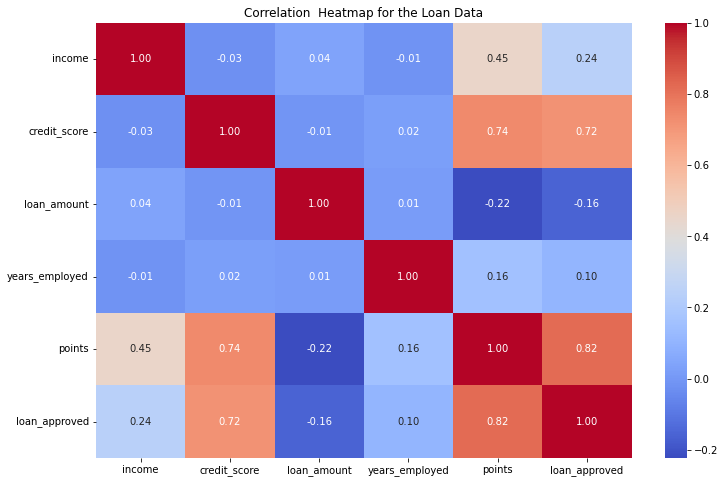

In [16]:
if numeric_loan_data.shape[1] >= 4:
    plt.figure(figsize=(12, 8))
    corr = numeric_loan_data.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation  Heatmap for the Loan Data')
else:
    print('No enough numeric Columns for the heatmap')

Text(0.5, 1.02, 'Pair Plot of the numeric values')

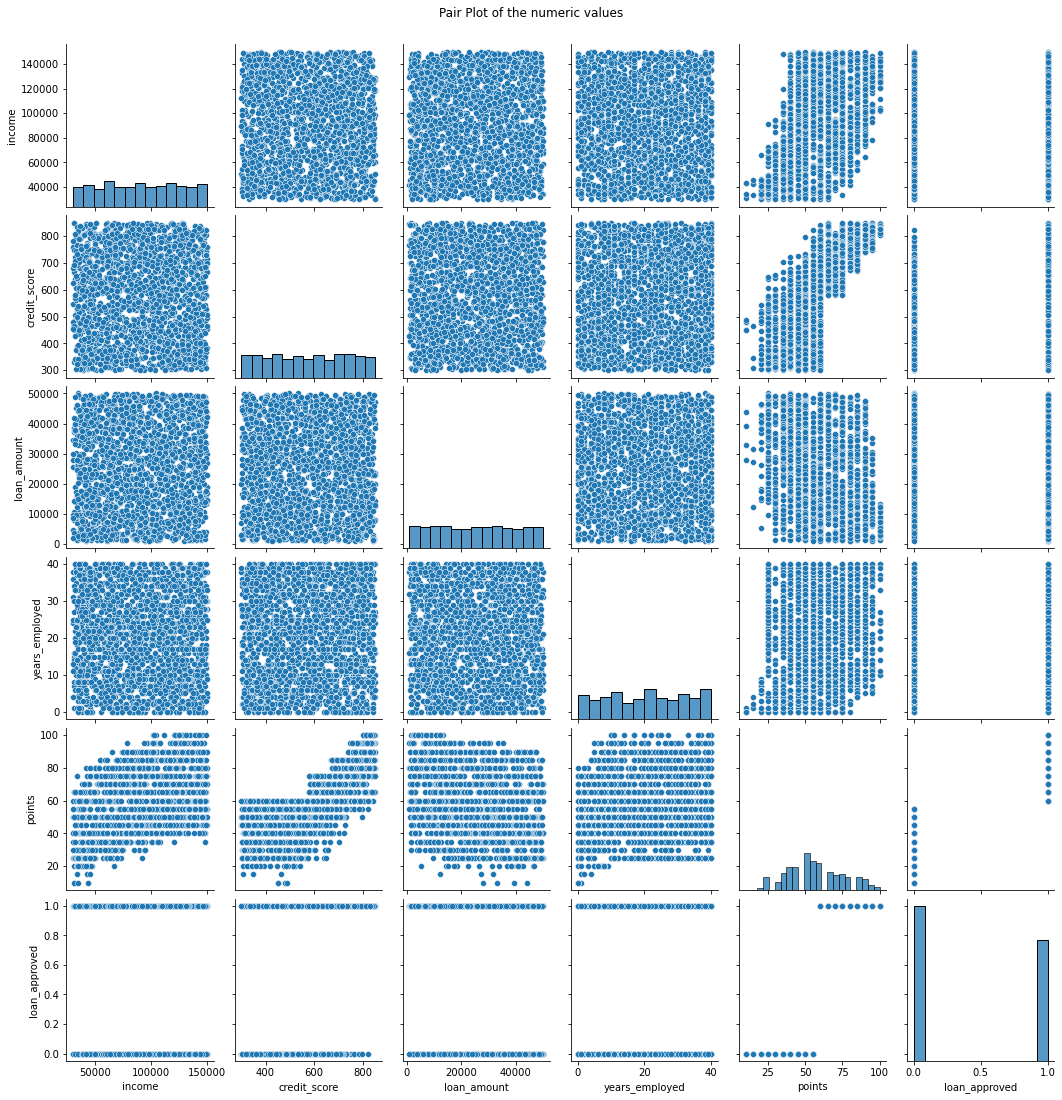

In [17]:
# Pair Plot
sns.pairplot(numeric_loan_data)
plt.suptitle('Pair Plot of the numeric values', y=1.02)

Text(0.5, 0.98, 'Histogram of Numeric Features')

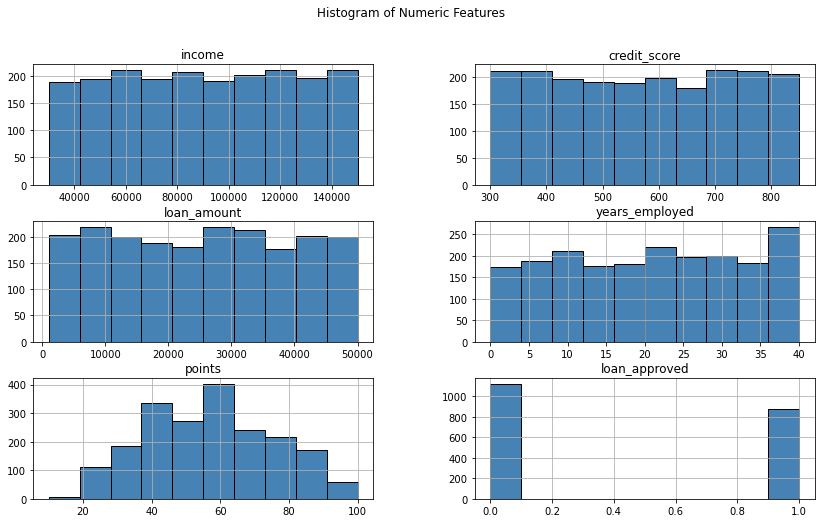

In [22]:
# Histograms for numeric columns
numeric_loan_data.hist(color='steelblue', figsize=(14, 8), edgecolor='black')
plt.suptitle('Histogram of Numeric Features')

<AxesSubplot:xlabel='loan_approved', ylabel='count'>

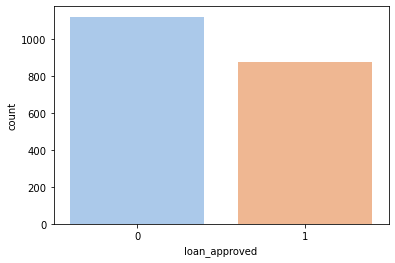

In [ ]:
# Count plot for the target variable 'loan_appro
plt.figure(figsize=(6, 4))
sns.countplot(data=loan_approval_data, palette='pastel', x='loan_approved')
plt.title('Loan Approval Count')

Text(0.5, 1.0, 'Loan Approval Boxplot')

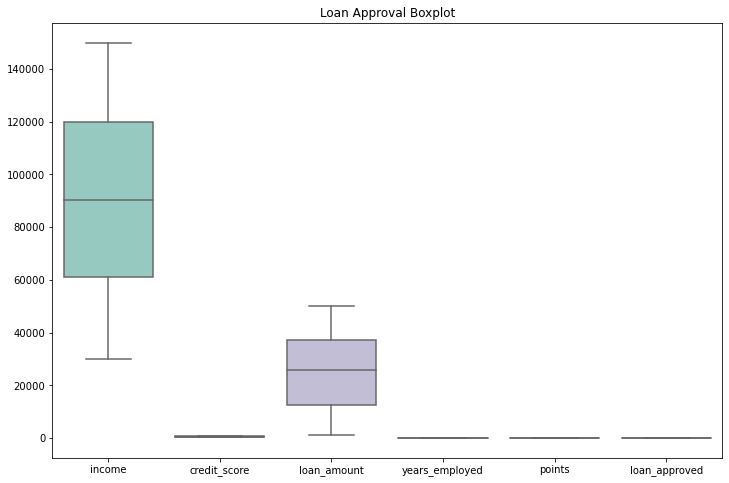

In [26]:
# Box Plot for selected features
plt.figure(figsize=(12, 8))
sns.boxplot(data=numeric_loan_data, palette='Set3')
plt.title('Loan Approval Boxplot')

## Prediction

We aim to build a predictive model that classifies whether a loan application is approved.
Since the dataset contains categorical features such as ‘city’, we apply one-hot encoding to transform these variables, while keeping numerical features unchanged. The data is then split into training and testing sets to evaluate model performance.

We assess the model using key metrics such as accuracy, and visualize results through a confusion matrix and ROC curve.
If any encoding or data-splitting issues arise, note that similar challenges are common in preprocessing pipelines — and the use of techniques like ColumnTransformer provides a robust, standardized solution.

In [40]:
# Define the feature set X and target y
X = loan_approval_data.drop(columns=['loan_approved'])
y = loan_approval_data['loan_approved']

# Identify categorical and numeric columns
categorical_columns = ['city']
numerical_columns = [column for column in X.columns if column not in categorical_columns]
print('Numerical Columns:  ', numerical_columns)
print('Categorical Columns:  ', categorical_columns)

Numerical Columns:   ['income', 'credit_score', 'loan_amount', 'years_employed', 'points']
Categorical Columns:   ['city']


In [47]:
# Create a ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns),
    ('num', 'passthrough', numerical_columns)
])

# Create a pipeline with preprocessing and logistic regression model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

# Fit the model
pipeline.fit(X_train, y_train)

# predict on the test data
y_pred = pipeline.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy of Logistic Regression classifier: {accuracy:.2f}')



Accuracy of Logistic Regression classifier: 0.83


In [ ]:
# Confusion Matrix
loan_confusion_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(loan_confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('The Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')